# Titanic Survival Prediction

This notebook explores the titanic passenger data and compares Logistic Regression, Decision Tree, and XGBoost models for predicting survival. Logistic Regression is the baseline model. 

The workflow uses a stratified train/test split, leakage-safe preprocessing pipelines, stratified cross-validation, and simple hyperparameter searches. Models are compared using accuracy, precision, recall, F1-score, ROC-AUC, Average Precision (AP), and confusion matrices. **F1 is the primary selection criterion and ROC-AUC is the secondary criterion.**


## Import Libraries and Setup


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    learning_curve,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost is required for this notebook. Install it with `%pip install xgboost`."
    ) from exc

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

In [2]:
# Create Dataframe and Split Train/Test data
df = pd.read_csv("data/train.csv")

X =df.drop(columns="Survived")
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print("Training survival rate:", y_train.mean().round(3))
print("Test survival rate:", y_test.mean().round(3))

Training rows: 712
Test rows: 179
Training survival rate: 0.383
Test survival rate: 0.385


## Feature Engineering and Preprocessing

The feature engineer reuses three variables created in the exploratory analysis: family size, traveling alone, and child status. The preprocessing pipeline then:

- fills missing age values with the median learned from each training fold before deriving child status;
- imputes the remaining numeric values with the training-fold median;
- standardizes numeric values for Logistic Regression only (tree-based models do not require scaling);
- imputes categorical values with the most frequent training-fold category; and
- one-hot encodes categories while safely handling unseen values.

Passenger ID, name, ticket, and cabin are not selected for modeling.


In [3]:
# Create Titanic features using values learned from each training fold.
class TitFeatEng(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.age_median_ = X["Age"].median()
        return self

    def transform(self, X):
        X = X.copy()
        X["Age"] = X["Age"].fillna(self.age_median_)
        X["FamilySize"] = X["SibSp"] + X["Parch"] + 1
        X["IsAlone"] = (X["FamilySize"] == 1).astype(int)
        X["IsChild"] = (X["Age"] < 18).astype(int)
        return X


numeric_features = [
    "Pclass", "Age", "SibSp", "Parch", "Fare",
    "FamilySize", "IsAlone", "IsChild",
]
categorical_features = ["Sex", "Embarked"]


def build_preprocessor(scale_numeric=False):
    # Scaling helps Logistic Regression but is unnecessary for tree-based models.
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])


def make_pipeline(classifier):
    # Only Logistic Regression receives scaled numeric features.
    scale_numeric = isinstance(classifier, LogisticRegression)
    return Pipeline([
        ("feature_engineering", TitFeatEng()),
        ("preprocessor", build_preprocessor(scale_numeric=scale_numeric)),
        ("classifier", classifier),
    ])


## Evaluation Functions

Cross-validation, hyperparameter tuning, threshold tuning, and model ranking use only training data.
The held-out test data is not used to fit or select a model; its metrics are reported separately to show performance on unseen passengers.


In [4]:
SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def calculate_metrics(y_true, y_pred, y_probability):
    # Return requested binary-classification metrics.
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_probability),
        "Average Precision (AP)": average_precision_score(y_true, y_probability),
    }

def train_and_evaluate(model_name, pipeline, X_train, y_train, X_test, y_test):
    # Cross-validate, fit, and evaluate one complete pipeline.
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_probability = pipeline.predict_proba(X_test)[:, 1]

    result = {"Model": model_name}
    result.update(calculate_metrics(y_test, y_pred, y_probability))
    for metric in SCORING:
        result[f"CV {metric.replace('_', ' ').title()} Mean"] = cv_results[
            f"test_{metric}"
        ].mean()
        result[f"CV {metric.replace('_', ' ').title()} Std"] = cv_results[
            f"test_{metric}"
        ].std()

    predictions = {
        "predicted": y_pred,
        "probability": y_probability,
    }
    return pipeline, result, predictions

def plot_confusion_matrices(fitted_models, X_test, y_test, thresholds=None):
    # Plot one confusion matrix for each fitted model.
    fig, axes = plt.subplots(1, len(fitted_models), figsize=(15, 4))
    axes = np.atleast_1d(axes)
    for ax, (name, model) in zip(axes, fitted_models.items()):
        if thresholds is None:
            y_pred = model.predict(X_test)
        else:
            probability = model.predict_proba(X_test)[:, 1]
            y_pred = (probability >= thresholds[name]).astype(int)
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            display_labels=["Did not survive", "Survived"],
            cmap="Blues",
            colorbar=False,
            ax=ax,
        )
        ax.set_title(name)
    plt.tight_layout()
    plt.show()

def plot_precision_recall_comparison(fitted_models, X_test, y_test):
    # Plot precision-recall curves with survivor prevalence as the no-skill baseline.
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, model in fitted_models.items():
        PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
    ax.axhline(y_test.mean(), color="black", linestyle="--", label="No skill")
    ax.set_title("Precision-Recall Curve Comparison - Held-Out Test Set")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_roc_comparison(fitted_models, X_test, y_test):
    # Plot all test-set ROC curves on one chart.
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, model in fitted_models.items():
        RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
    ax.plot([0, 1], [0, 1], "k--", label="Chance")
    ax.set_title("ROC Curve Comparison — Held-Out Test Set")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## Baseline Model Comparison

Logistic Regression is the required baseline. The Decision Tree and XGBoost models below use straightforward default settings before tuning.


In [5]:
models = {
    "Logistic Regression (Baseline)": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.10,
        subsample=1.0,
        colsample_bytree=1.0,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

baseline_fitted = {}
baseline_results = []
baseline_predictions = {}

for model_name, classifier in models.items():
    fitted, result, predictions = train_and_evaluate(
        model_name,
        make_pipeline(classifier),
        X_train,
        y_train,
        X_test,
        y_test,
    )
    baseline_fitted[model_name] = fitted
    baseline_results.append(result)
    baseline_predictions[model_name] = predictions

baseline_comparison = pd.DataFrame(baseline_results).set_index("Model")
baseline_comparison.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision (AP),CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV Roc Auc Mean,CV Roc Auc Std,CV Average Precision Mean,CV Average Precision Std
Model,,,,,,,,,,,,,,,,,,
Logistic Regression (Baseline),0.821,0.814,0.696,0.750,0.857,0.810,0.806,0.022,0.765,0.043,0.718,0.026,0.740,0.025,0.855,0.027,0.834,0.029
Decision Tree,0.799,0.746,0.725,0.735,0.779,0.652,0.780,0.025,0.715,0.034,0.707,0.039,0.711,0.033,0.767,0.028,0.623,0.035
XGBoost,0.804,0.804,0.652,0.720,0.821,0.787,0.816,0.030,0.802,0.078,0.703,0.036,0.746,0.033,0.884,0.024,0.864,0.031


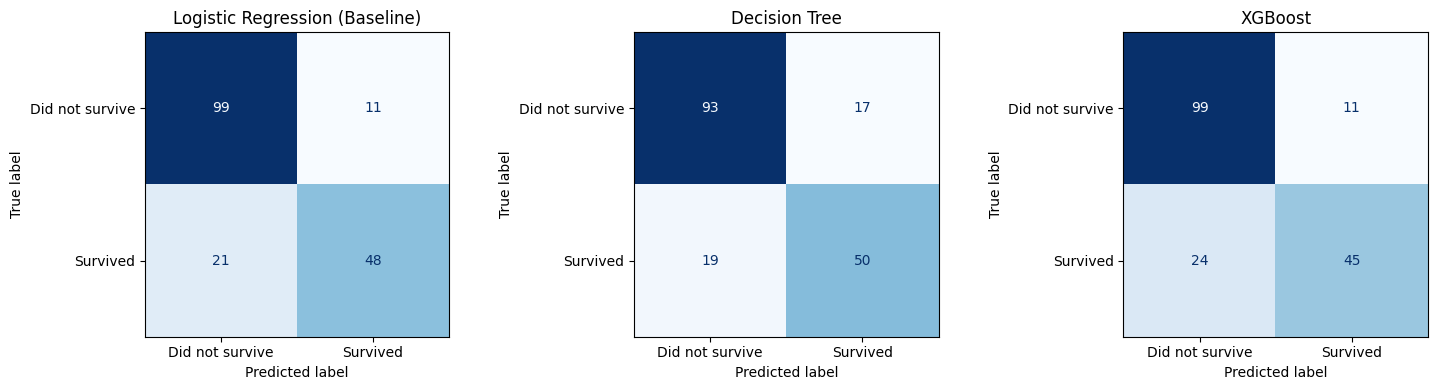

In [6]:
plot_confusion_matrices(baseline_fitted, X_test, y_test)

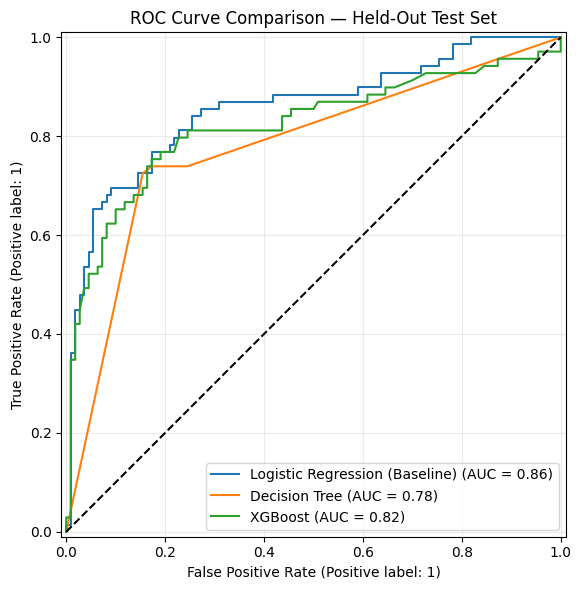

In [7]:
plot_roc_comparison(baseline_fitted, X_test, y_test)

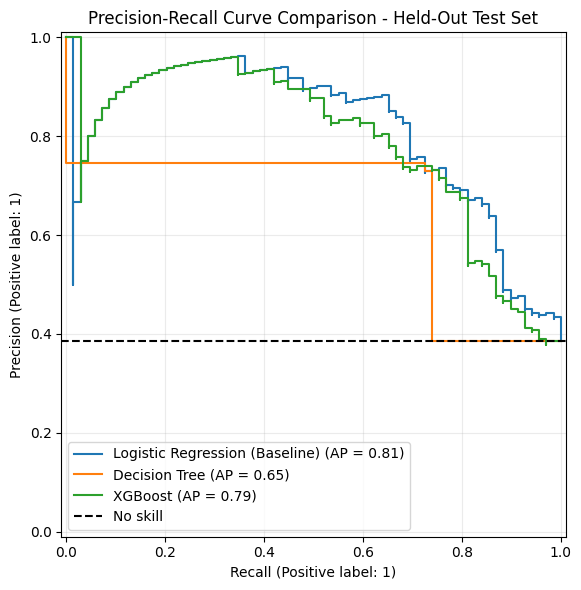

In [8]:
plot_precision_recall_comparison(baseline_fitted, X_test, y_test)

## Hyperparameter Tuning

Each search uses same stratified folds and evaluates F1, ROC-AUC, and Average Precision (AP). The search is refit on **F1**, because it directly balances precision and recall for the survivor class. ROC-AUC is retained as the secondary selection criterion, while Average Precision (AP) provides an additional view focused on the positive survivor class. XGBoost also tests the training-set negative-to-positive class ratio through `scale_pos_weight`.


In [9]:
# A value above 1 gives more training weight to survivor-class errors.
negative_to_positive_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Training negative-to-positive ratio: {negative_to_positive_ratio:.3f}")

parameter_grids = {
    "Logistic Regression": {
        "classifier__C": [0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"],
        "classifier__solver": ["liblinear"],
    },
    "Decision Tree": {
        "classifier__max_depth": [3, 5, 8, None],
        "classifier__min_samples_split": [2, 10, 20],
        "classifier__min_samples_leaf": [1, 5, 10],
        "classifier__class_weight": [None, "balanced"],
    },
    "XGBoost": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [2, 3, 5],
        "classifier__learning_rate": [0.05, 0.10],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0],
        "classifier__scale_pos_weight": [1.0, negative_to_positive_ratio],
    },
}

def tune_model(model_name, pipeline, parameter_grid, X_train, y_train):
    # Tune one pipeline with stratified CV and refit the best F1 model.
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grid,
        scoring={
            "f1": "f1",
            "roc_auc": "roc_auc",
            "average_precision": "average_precision",
        },
        refit="f1",
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )
    search.fit(X_train, y_train)
    print(f"{model_name} best CV F1: {search.best_score_:.3f}")
    print(f"{model_name} best parameters: {search.best_params_}")
    print()
    return search

def tune_f1_threshold(model, X_train, y_train):
    # Use out-of-fold training probabilities so the held-out test set stays untouched.
    oof_probability = cross_val_predict(
        clone(model),
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_train, oof_probability)
    denominator = precision + recall
    f1_values = np.divide(
        2 * precision * recall,
        denominator,
        out=np.zeros_like(denominator),
        where=denominator != 0,
    )
    best_index = np.argmax(f1_values[:-1])

    return {
        "threshold": thresholds[best_index],
        "cv_f1": f1_values[best_index],
        "cv_roc_auc": roc_auc_score(y_train, oof_probability),
        "cv_average_precision": average_precision_score(y_train, oof_probability),
    }


Training negative-to-positive ratio: 1.608


In [10]:
tuning_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

tuning_searches = {}

for model_name, classifier in tuning_models.items():
    tuning_searches[model_name] = tune_model(
        model_name,
        make_pipeline(classifier),
        parameter_grids[model_name],
        X_train,
        y_train,
    )

Logistic Regression best CV F1: 0.743
Logistic Regression best parameters: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}

Decision Tree best CV F1: 0.743
Decision Tree best parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}

XGBoost best CV F1: 0.772
XGBoost best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 1.6080586080586081, 'classifier__subsample': 1.0}



## Final Tuned Model Comparison

The table reports all requested held-out test metrics plus Average Precision (AP). For each tuned model, the classification threshold is selected using out-of-fold training probabilities to maximize F1; the held-out test set is not used to choose the threshold. Models are ranked first by **CV F1** and then by **CV ROC-AUC** as the secondary criterion.

Model selection is based on cross-validation rather than test performance. Held-out metrics are reported for comparison but do not determine the winner.


In [11]:
final_models = {}
final_thresholds = {}
final_rows = []

for model_name, search in tuning_searches.items():
    best_model = search.best_estimator_
    threshold_results = tune_f1_threshold(best_model, X_train, y_train)
    decision_threshold = threshold_results["threshold"]
    y_probability = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_probability >= decision_threshold).astype(int)

    row = {"Model": model_name}
    row.update(calculate_metrics(y_test, y_pred, y_probability))
    row["Decision Threshold"] = decision_threshold
    row["CV F1"] = threshold_results["cv_f1"]
    row["CV ROC-AUC"] = threshold_results["cv_roc_auc"]
    row["CV Average Precision"] = threshold_results["cv_average_precision"]
    row["Best Parameters"] = search.best_params_

    final_models[model_name] = best_model
    final_thresholds[model_name] = decision_threshold
    final_rows.append(row)

final_comparison = (
    pd.DataFrame(final_rows)
    .sort_values(
        ["CV F1", "CV ROC-AUC"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display_columns = [
    "Model", "Decision Threshold", "Accuracy", "Precision", "Recall",
    "F1", "ROC-AUC", "Average Precision (AP)", "CV F1", "CV ROC-AUC",
    "CV Average Precision",
]
final_comparison[display_columns].round(3)


,Model,Decision Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision (AP),CV F1,CV ROC-AUC,CV Average Precision
0,XGBoost,0.422,0.793,0.722,0.754,0.738,0.829,0.779,0.778,0.880,0.855
1,Logistic Regression,0.320,0.771,0.659,0.841,0.739,0.856,0.811,0.749,0.856,0.829
2,Decision Tree,0.468,0.777,0.723,0.681,0.701,0.804,0.767,0.746,0.828,0.794


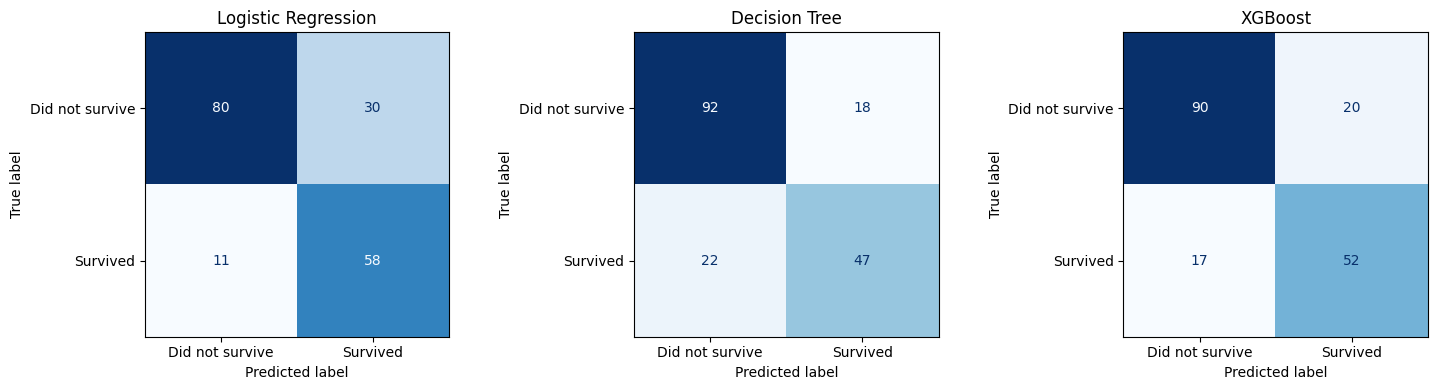

In [12]:
plot_confusion_matrices(final_models, X_test, y_test, final_thresholds)

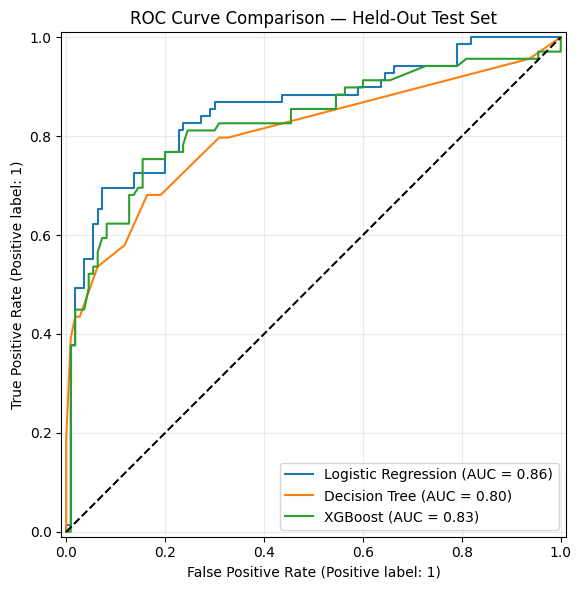

In [13]:
plot_roc_comparison(final_models, X_test, y_test)

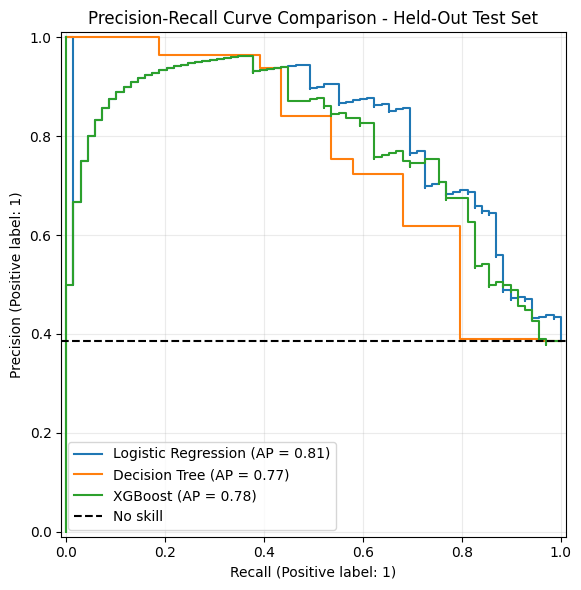

In [14]:
plot_precision_recall_comparison(final_models, X_test, y_test)

## Best Model and Conclusion

The winner is chosen using **out-of-fold cross-validated F1 as the primary criterion** and **out-of-fold ROC-AUC as the secondary criterion**. The decision threshold is learned only from training-fold predictions. Accuracy, precision, recall, Average Precision (AP), and the held-out confusion matrices remain important supporting evidence.


In [15]:
best_row = final_comparison.iloc[0]
best_model_name = best_row["Model"]
best_model = final_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Decision threshold: {best_row['Decision Threshold']:.3f}")
print(f"Cross-validated F1: {best_row['CV F1']:.3f}")
print(f"Cross-validated ROC-AUC: {best_row['CV ROC-AUC']:.3f}")
print(f"Cross-validated Average Precision: {best_row['CV Average Precision']:.3f}")
print(f"Held-out test F1: {best_row['F1']:.3f}")
print(f"Held-out test ROC-AUC: {best_row['ROC-AUC']:.3f}")
print(f"Held-out test Average Precision: {best_row['Average Precision (AP)']:.3f}")
print("Best parameters:", best_row["Best Parameters"])


Best model: XGBoost
Decision threshold: 0.422
Cross-validated F1: 0.778
Cross-validated ROC-AUC: 0.880
Cross-validated Average Precision: 0.855
Held-out test F1: 0.738
Held-out test ROC-AUC: 0.829
Held-out test Average Precision: 0.779
Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 1.6080586080586081, 'classifier__subsample': 1.0}


## Learning Curve: Final Model

The learning curve retrains the selected pipeline on progressively larger portions of the training data and reports mean training and validation F1 across the same stratified folds. It uses the classifier's standard prediction rule within each fold and does **not** use the held-out test set.

A large persistent gap between training and validation F1 suggests overfitting. Low, converged scores suggest underfitting. Convergence at a strong F1 suggests that additional training data may offer smaller gains.


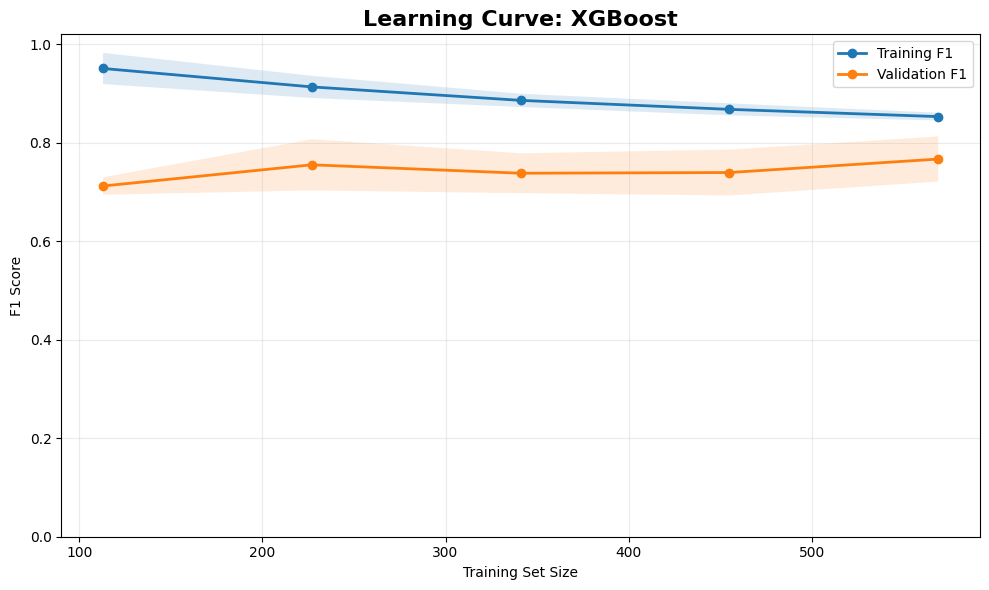

In [16]:
def plot_f1_learning_curve(
    model,
    X,
    y,
    model_name,
    train_sizes=np.linspace(0.20, 1.00, 5),
):
    # Standard F1 scoring keeps every validation fold independent of threshold tuning.
    sizes, training_scores, validation_scores = learning_curve(
        estimator=clone(model),
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring="f1",
        shuffle=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    training_mean = training_scores.mean(axis=1)
    training_std = training_scores.std(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, training_mean, marker="o", linewidth=2, label="Training F1")
    plt.plot(sizes, validation_mean, marker="o", linewidth=2, label="Validation F1")
    plt.fill_between(
        sizes, training_mean - training_std, training_mean + training_std, alpha=0.15
    )
    plt.fill_between(
        sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.15
    )
    plt.title(f"Learning Curve: {model_name}", fontsize=16, weight="bold")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.ylim(0, 1.02)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        "Training Set Size": sizes,
        "Training F1 Mean": training_mean,
        "Training F1 Std": training_std,
        "Validation F1 Mean": validation_mean,
        "Validation F1 Std": validation_std,
    })


learning_curve_results = plot_f1_learning_curve(
    model=best_model,
    X=X_train,
    y=y_train,
    model_name=best_model_name,
)

# learning_curve_results.round(3)


In [17]:
from IPython.display import display, Markdown

final_curve_row = learning_curve_results.iloc[-1]
training_f1 = final_curve_row["Training F1 Mean"]
validation_f1 = final_curve_row["Validation F1 Mean"]
learning_gap = training_f1 - validation_f1

if learning_gap >= 0.10:
    gap_interpretation = "a substantial generalization gap, suggesting overfitting"
elif learning_gap >= 0.05:
    gap_interpretation = "a moderate generalization gap, suggesting some remaining variance"
else:
    gap_interpretation = "a small generalization gap, suggesting stable generalization"

if len(learning_curve_results) > 1:
    validation_change = (
        validation_f1 - learning_curve_results.iloc[-2]["Validation F1 Mean"]
    )
else:
    validation_change = 0.0

if validation_change > 0.01:
    curve_interpretation = "The validation curve is still rising, so additional data may help."
elif validation_change < -0.01:
    curve_interpretation = "The final validation point declined, so model variance should be monitored."
else:
    curve_interpretation = "The validation curve is stabilizing, so additional data may provide smaller gains."

summary = f"""
## Interpretation and Final Takeaways

- **F1-score** is emphasized because it balances precision and recall for predicting survivors.
- **ROC-AUC** measures how well a model separates survivors from non-survivors across classification thresholds.
- **Average Precision (AP)** summarizes precision-recall performance and focuses on the positive survivor class.
- **Threshold tuning** uses out-of-fold training probabilities to maximize F1 without using held-out test labels.
- **XGBoost class weighting** tests both the default and the training-set negative-to-positive ratio.
- **Accuracy** provides an overall success rate, while precision and recall clarify the types of errors made.
- **Confusion matrices** show the exact counts of true negatives, false positives, false negatives, and true positives.
- **Selected model:** {best_model_name}, based on training-only CV F1 = {best_row['CV F1']:.3f} and CV ROC-AUC = {best_row['CV ROC-AUC']:.3f}.
- **Held-out performance:** F1 = {best_row['F1']:.3f}, ROC-AUC = {best_row['ROC-AUC']:.3f}, and Average Precision = {best_row['Average Precision (AP)']:.3f}.
- **Learning curve:** at {int(final_curve_row['Training Set Size'])} training rows, training F1 = {training_f1:.3f} and validation F1 = {validation_f1:.3f}. This is {gap_interpretation}. {curve_interpretation}
"""

display(Markdown(summary))


## Interpretation and Final Takeaways

- **F1-score** is emphasized because it balances precision and recall for predicting survivors.
- **ROC-AUC** measures how well a model separates survivors from non-survivors across classification thresholds.
- **Average Precision (AP)** summarizes precision-recall performance and focuses on the positive survivor class.
- **Threshold tuning** uses out-of-fold training probabilities to maximize F1 without using held-out test labels.
- **XGBoost class weighting** tests both the default and the training-set negative-to-positive ratio.
- **Accuracy** provides an overall success rate, while precision and recall clarify the types of errors made.
- **Confusion matrices** show the exact counts of true negatives, false positives, false negatives, and true positives.
- **Selected model:** XGBoost, based on training-only CV F1 = 0.778 and CV ROC-AUC = 0.880.
- **Held-out performance:** F1 = 0.738, ROC-AUC = 0.829, and Average Precision = 0.779.
- **Learning curve:** at 569 training rows, training F1 = 0.853 and validation F1 = 0.767. This is a moderate generalization gap, suggesting some remaining variance. The validation curve is still rising, so additional data may help.


### References

- Brownlee, J. (2020). *Imbalanced Classification with Python* (v1.31), especially Chapters 7, 20, and 21 on Average Precision (AP), class-weighted XGBoost, and probability-threshold tuning.
- Brownlee, J. (2021). *Ensemble Learning Algorithms with Python* (v1.11), especially the gradient-boosting guidance on jointly tuning ensemble size, learning rate, and subsampling.
- Brownlee, J. (2016). *XGBoost with Python* (v1.16), especially Chapters 10, 13, and 15 on controlling overfitting and tuning tree count, depth, learning rate, and sampling.

The implementation adapts the threshold-tuning recommendation by using out-of-fold training predictions instead of the held-out test set, preserving the test set for final evaluation.
